In [1]:
import numpy as np
import pandas as pd

print("Библиотеки успешно подключены!")

Библиотеки успешно подключены!


In [2]:
# Фиксируем случайные числа для одинакового результата
np.random.seed(42)
n_samples = 10000

# Словари и списки для генерации данных
car_catalog = {
    "Hyundai": ["ix35", "Tucson", "Solaris", "Santa Fe"],
    "Kia": ["Rio", "Sportage", "Ceed", "Optima"],
    "Toyota": ["Camry", "RAV4", "Corolla", "Land Cruiser"],
    "BMW": ["3 Series", "5 Series", "X5", "X3"],
    "Volkswagen": ["Polo", "Tiguan", "Passat", "Golf"],
}

transmissions = ["Автомат", "Механика", "Робот"]
drivetrains = ["Передний", "Полный", "Задний"]
bodies = ["Кроссовер", "Седан", "Хэтчбек"]

data = []

for _ in range(n_samples):
    brand = np.random.choice(list(car_catalog.keys()))
    model = np.random.choice(car_catalog[brand])
    year = int(np.random.randint(2008, 2025))

    # Возраст и пробег
    age = 2026 - year
    base_km = age * np.random.normal(15000, 4000)
    km = max(0, int(base_km))

    transmission = np.random.choice(
        transmissions, p=[0.6, 0.3, 0.1]
    )  # 60% автомата
    drivetrain = np.random.choice(drivetrains, p=[0.5, 0.4, 0.1])
    body = np.random.choice(bodies)

    # Базовая цена в зависимости от бренда
    base_price = 2_500_000
    if brand in ["BMW", "Toyota"]:
        base_price *= 1.4
    elif brand in ["Hyundai", "Kia", "Volkswagen"]:
        base_price *= 0.85

    # Зависимость цены от возраста и пробега
    price = base_price * (0.91**age) - (km * 3.5)
    price = max(300_000, price)
    price *= np.random.uniform(0.85, 1.15)
    price = int(price)

    data.append(
        [
            brand,
            model,
            year,
            km,
            transmission,
            drivetrain,
            body,
            price,
        ]
    )

df_raw = pd.DataFrame(
    data,
    columns=[
        "brand",
        "model",
        "year",
        "km",
        "transmission",
        "drivetrain",
        "body",
        "price",
    ],
)

# Добавляем "грязные" данные (пропуски и аномалии)
df_raw.loc[df_raw.sample(frac=0.03).index, "km"] = np.nan
df_raw.loc[df_raw.sample(frac=0.02).index, "transmission"] = np.nan

# Ошибки в ценах (выбросы)
df_raw.loc[df_raw.sample(n=15).index, "price"] = np.random.choice(
    [15_000_000, 50_000, 99_999_999]
)

# Сохраняем в CSV файл
df_raw.to_csv("used_cars_raw.csv", index=False)
print("✅ Файл 'used_cars_raw.csv' успешно создан!")

✅ Файл 'used_cars_raw.csv' успешно создан!


In [3]:
# Загружаем сырой файл обратно в переменную df
df = pd.read_csv("used_cars_raw.csv")

# Показываем первые 5 строк
print("--- ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ ---")
display(df.head())

# Показываем общую информацию о типах данных и пропусках
print("\n--- ИНФОРМАЦИЯ О КОЛОНКАХ И ПРОПУСКАХ ---")
df.info()

--- ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ ---


,brand,model,year,km,transmission,drivetrain,body,price
0,BMW,3 Series,2022,70363.0,Автомат,Передний,Хэтчбек,2127521
1,Volkswagen,Golf,2015,232013.0,Механика,Передний,Седан,319979
2,Kia,Optima,2008,287421.0,NaN,Передний,Хэтчбек,290987
3,BMW,X3,2023,22040.0,Автомат,Передний,Седан,2329675
4,BMW,X3,2010,266688.0,Автомат,Передний,Кроссовер,341906



--- ИНФОРМАЦИЯ О КОЛОНКАХ И ПРОПУСКАХ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         10000 non-null  object 
 1   model         10000 non-null  object 
 2   year          10000 non-null  int64  
 3   km            9700 non-null   float64
 4   transmission  9800 non-null   object 
 5   drivetrain    10000 non-null  object 
 6   body          10000 non-null  object 
 7   price         10000 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 625.1+ KB


In [4]:
# Считаем количество пропущенных значений в каждой колонке
missing_values = df.isnull().sum()
print("--- КОЛИЧЕСТВО ПРОПУСКОВ В КОЛОНКАХ ---")
print(missing_values)

--- КОЛИЧЕСТВО ПРОПУСКОВ В КОЛОНКАХ ---
brand             0
model             0
year              0
km              300
transmission    200
drivetrain        0
body              0
price             0
dtype: int64


In [5]:
# 1. Заполняем пробег медианой по году выпуска машины
df["km"] = df.groupby("year")["km"].transform(
    lambda x: x.fillna(x.median())
)

# 2. Заполняем коробку передач самым частым значением
most_frequent_transmission = df["transmission"].mode()[0]
df["transmission"] = df["transmission"].fillna(most_frequent_transmission)

# Проверяем, остались ли пропуски
print("Пропусков после обработки:", df.isnull().sum().sum())

Пропусков после обработки: 0


In [6]:
# Посмотрим на базовую статистику до фильтрации
print("Мин. цена ДО:", df["price"].min(), "Макс. цена ДО:", df["price"].max())

# Фильтруем адекватные границы рынка:
# Цена от 150 000 до 12 000 000 рублей
# Пробег от 100 км
df_clean = df[
    (df["price"] >= 150_000)
    & (df["price"] <= 12_000_000)
    & (df["km"] >= 100)
].copy()

print(
    "Мин. цена ПОСЛЕ:",
    df_clean["price"].min(),
    "Макс. цена ПОСЛЕ:",
    df_clean["price"].max(),
)
print(f"Удалено аномальных строк: {len(df) - len(df_clean)}")

Мин. цена ДО: 255043 Макс. цена ДО: 99999999
Мин. цена ПОСЛЕ: 255043 Макс. цена ПОСЛЕ: 3259095
Удалено аномальных строк: 15


In [7]:
# 1. Возраст автомобиля
df_clean["car_age"] = 2026 - df_clean["year"]

# Если машина 2026 года (возраст 0), заменим на 1, чтобы не делить на ноль
age_for_calc = df_clean["car_age"].replace(0, 1)

# 2. Среднегодовой пробег (округляем до целого)
df_clean["km_per_year"] = (df_clean["km"] / age_for_calc).round(0).astype(int)

# Посмотрим на первые 5 строк очищенной таблицы с новыми метриками
display(
    df_clean[
        ["brand", "model", "year", "car_age", "km", "km_per_year", "price"]
    ].head()
)

,brand,model,year,car_age,km,km_per_year,price
0,BMW,3 Series,2022,4,70363.0,17591,2127521
1,Volkswagen,Golf,2015,11,232013.0,21092,319979
2,Kia,Optima,2008,18,287421.0,15968,290987
3,BMW,X3,2023,3,22040.0,7347,2329675
4,BMW,X3,2010,16,266688.0,16668,341906


In [8]:
# Сохраняем очищенные данные
df_clean.to_csv("used_cars_clean.csv", index=False)
print(
    "✅ Очищенный файл 'used_cars_clean.csv' успешно сохранен и готов к работе!"
)

✅ Очищенный файл 'used_cars_clean.csv' успешно сохранен и готов к работе!


In [9]:
import sqlite3

# Создаем или подключаемся к базе данных SQLite
conn = sqlite3.connect("cars_database.db")

# Загружаем очищенный датасет df_clean в таблицу 'cars'
df_clean.to_sql("cars", conn, if_exists="replace", index=False)

print(
    "✅ База данных 'cars_database.db' создана, таблица 'cars' успешно загружена!"
)

✅ База данных 'cars_database.db' создана, таблица 'cars' успешно загружена!


In [10]:
query_1 = """
SELECT
    brand,
    COUNT(*) as total_cars,
    ROUND(AVG(price), 0) as avg_price,
    ROUND(AVG(car_age), 1) as avg_age,
    ROUND(AVG(km), 0) as avg_km
FROM cars
GROUP BY brand
ORDER BY total_cars DESC;
"""

# Выполняем SQL-запрос и оборачиваем результат в читаемый DataFrame
df_res_1 = pd.read_sql_query(query_1, conn)
display(df_res_1)

,brand,total_cars,avg_price,avg_age,avg_km
0,Volkswagen,2018,634294.0,10.0,149936.0
1,BMW,2012,1096794.0,10.0,148452.0
2,Kia,2006,641183.0,10.0,149701.0
3,Toyota,1988,1073888.0,10.2,152326.0
4,Hyundai,1961,649274.0,9.9,147306.0


In [11]:
query_2 = """
SELECT
    brand,
    model,
    year,
    price,
    -- Считаем среднюю цену для такой же модели того же года
    ROUND(AVG(price) OVER(PARTITION BY model, year), 0) as avg_model_year_price,
    -- Показываем разницу в ценах
    ROUND(price - AVG(price) OVER(PARTITION BY model, year), 0) as price_diff
FROM cars
ORDER BY price_diff DESC
LIMIT 10;
"""

df_res_2 = pd.read_sql_query(query_2, conn)
display(df_res_2)

,brand,model,year,price,avg_model_year_price,price_diff
0,Toyota,Camry,2014,1030639,495050.0,535589.0
1,Toyota,Camry,2015,1234398,706599.0,527799.0
2,BMW,X5,2014,1068051,543443.0,524608.0
3,BMW,3 Series,2024,3259095,2771476.0,487619.0
4,Toyota,Corolla,2014,1011510,525850.0,485660.0
5,BMW,X3,2012,813473,348827.0,464646.0
6,BMW,X5,2014,994554,543443.0,451111.0
7,Hyundai,ix35,2018,1068737,621233.0,447504.0
8,BMW,X5,2023,2861187,2413872.0,447315.0
9,BMW,X5,2017,1487904,1043895.0,444009.0


In [12]:
query_3 = """
WITH RankedCars AS (
    SELECT
        brand,
        model,
        year,
        price,
        km,
        -- Присваиваем порядковый номер каждой машине внутри группы (модели), сортируя от дешевых к дорогим
        ROW_NUMBER() OVER(PARTITION BY model ORDER BY price ASC) as price_rank
    FROM cars
    WHERE car_age <= 5
)
SELECT brand, model, year, price, km
FROM RankedCars
WHERE price_rank = 1
ORDER BY price ASC;
"""

df_res_3 = pd.read_sql_query(query_3, conn)
display(df_res_3)

,brand,model,year,price,km
0,Hyundai,Santa Fe,2021,783365,116231.0
1,Volkswagen,Golf,2021,845320,99914.0
2,Volkswagen,Polo,2021,846744,114704.0
3,Kia,Optima,2021,862512,100077.0
4,Kia,Ceed,2021,863031,109892.0
5,Hyundai,ix35,2021,866455,100929.0
6,Kia,Sportage,2021,868875,87723.0
7,Hyundai,Tucson,2021,870832,101888.0
8,Volkswagen,Tiguan,2021,872969,98595.0
9,Kia,Rio,2021,876052,99780.0


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Библиотеки визуализации настроены!")

Библиотеки визуализации настроены!


/tmp/ipykernel_689/601203925.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


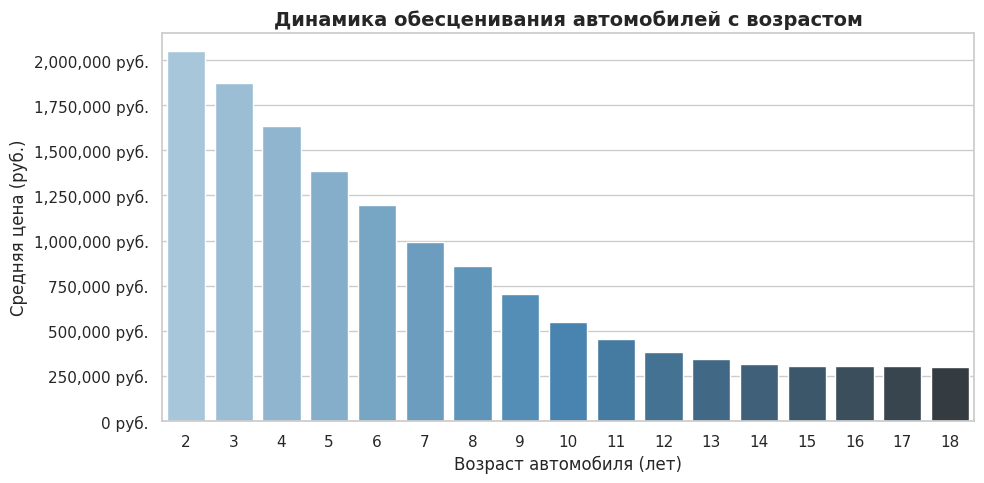

In [14]:
# Группируем данные по возрасту и считаем среднюю цену
price_by_age = (
    df_clean.groupby("car_age")["price"].mean().reset_index()
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=price_by_age, x="car_age", y="price", palette="Blues_d"
)

plt.title(
    "Динамика обесценивания автомобилей с возрастом",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Возраст автомобиля (лет)", fontsize=12)
plt.ylabel("Средняя цена (руб.)", fontsize=12)

# Форматируем ось Y, чтобы миллионы рублей читались легко
ax.yaxis.set_major_formatter("{x:,.0f} руб.")

plt.tight_layout()
# Сохраняем график в файл для GitHub
plt.savefig("price_depreciation.png", dpi=300)
plt.show()

/tmp/ipykernel_689/2741658735.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


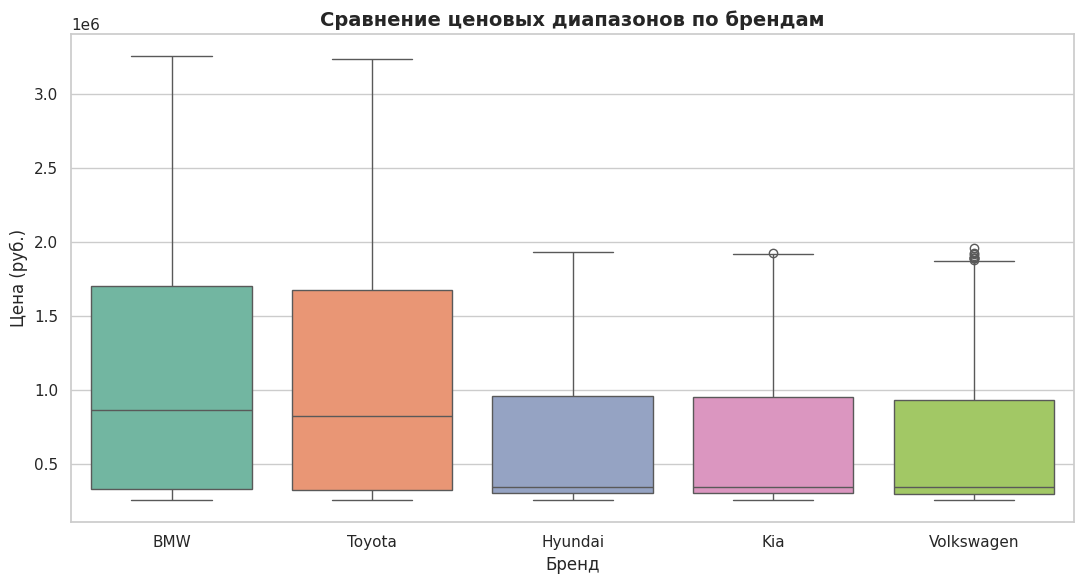

In [15]:
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_clean,
    x="brand",
    y="price",
    palette="Set2",
    order=["BMW", "Toyota", "Hyundai", "Kia", "Volkswagen"],
)

plt.title(
    "Сравнение ценовых диапазонов по брендам", fontsize=14, fontweight="bold"
)
plt.xlabel("Бренд", fontsize=12)
plt.ylabel("Цена (руб.)", fontsize=12)

plt.tight_layout()
plt.savefig("price_distribution_by_brand.png", dpi=300)
plt.show()

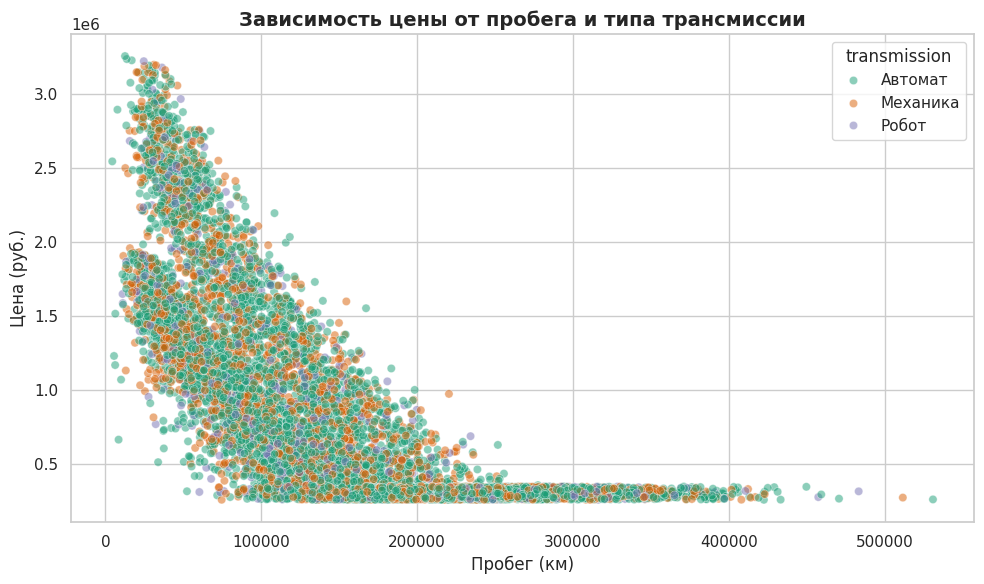

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="km",
    y="price",
    hue="transmission",
    alpha=0.5,
    palette="Dark2",
)

plt.title(
    "Зависимость цены от пробега и типа трансмиссии",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Пробег (км)", fontsize=12)
plt.ylabel("Цена (руб.)", fontsize=12)

plt.tight_layout()
plt.savefig("price_vs_km_scatter.png", dpi=300)
plt.show()

In [17]:
from google.colab import files

# Скачиваем CSV и графики
files.download("used_cars_clean.csv")
files.download("price_depreciation.png")
files.download("price_distribution_by_brand.png")
files.download("price_vs_km_scatter.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>